# STAT 207 Project 01 - Video Games Sales by Console

Tara Vittal, Jaclyn Rizzo

## 1. Introduction

We chose to use the Video Games dataset to explore, first because we are both avid video game enjoyers. We thought that there was an interesting variation of games. Another interesting thing about the dataset was the variables, such as FirstPerson and SideScrolling, as it gives good insight into the game mechanics. 

What is the relationship between the console type and the number of US Sales in millions in the dataset?

Answering this question could be important to a variety of groups. The answer could be important to someone working a game development studio. Knowing the relationship between console type and US sales volume could help them predict which platform gives you the best chance of maximizing revenue. Retail chains such as GameStop can know how much shelf space to allocate for various consoles. This information can even help investors, as US sales, compared to competitors, signal market position and influence.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns   
sns.set()  

In [3]:
df = pd.read_csv("video_games.csv", encoding="unicode_escape")
df.head()

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


## 2. Dataset Discussion

The dataset comes from the Video Game Sales with Ratings dataset, which is hosted on Kaggle.

Link: https://researchportal.port.ac.uk/en/datasets/video-games-dataset 

Accessed: September 19, 2025

Codebook: The Kaggle page provides a description of variables such as Title, Console, YearReleased, US Sales (millions), Publisher, Genre, and review-related fields.

This was originally collected and curated by Dr. Joe Cox

In [4]:
df.head(6), df.shape

(       Console                       Title  US Sales (millions)  Block4  \
 0  Nintendo DS           Super Mario 64 DS                 4.69       1   
 1     Sony PSP      Lumines: Puzzle Fusion                 0.56       0   
 2  Nintendo DS          WarioWare Touched!                 0.54       0   
 3     Sony PSP    Hot Shots Golf: Open Tee                 0.49       0   
 4  Nintendo DS                Spider-Man 2                 0.45       0   
 5  Nintendo DS  The Urbz: Sims in the City                 0.41       0   
 
    Block2  Block1  Block0.5  YearReleased  2004  2005  ...  Tricks  \
 0       1       1         1          2004     1     0  ...       0   
 1       0       0         1          2004     1     0  ...       0   
 2       0       0         1          2004     1     0  ...       0   
 3       0       0         0          2004     1     0  ...       0   
 4       0       0         0          2004     1     0  ...       0   
 5       0       0         0          20

The unit of observation is a single console brand. 

The two variables we are focusing on are console type, which is categorical, and US Sales in millions, which is quantitative. 

Some limitations are that the dataset does not include player engagement, profitability, or demographic information. Sales numbers show how many units were purchased, but they do not reveal how much people actually play the games, how loyal they are to a franchise, or how profitable the game was. For example, a game may sell millions of copies but see very low playtime, while another game with less sales might have high engagement and a more dedicated fan base allowing for long-term revenue. Without profitability data, it is also impossible to know if a game was truly successful, since high sales do not guarantee a profit. Lastly, a lack of information such as age, gender, or region further limits insights into who is buying and playing these games. 

## 3. Dataset Cleaning

In [5]:
pd.set_option("display.max_rows", None) 
df.isna().sum()

Console                       0
Title                         0
US Sales (millions)           0
Block4                        0
Block2                        0
Block1                        0
Block0.5                      0
YearReleased                  0
2004                          0
2005                          0
2006                          0
2007                          0
2008                          0
2009                          0
2010                          0
YearReleasedSq                0
Publisher                     0
Genre                         0
Sequel                        0
Re-release                    0
Usedprice                     0
lnUsedPrice                   0
Review Score                  0
ReviewSq                      0
RatingE                       0
RatingT                       0
RatingM                       0
Lifecycle                     0
LifecycleSq                   0
MaxPlayers                    0
MaxPlayersSq                  0
Online  

The dataset does not contain missing values, therefore the no missing values will be dropped.

In [6]:
df["US Sales (millions)"].describe()

count    1770.000000
mean        0.479785
std         1.064915
min         0.010000
25%         0.090000
50%         0.190000
75%         0.450000
max        14.660000
Name: US Sales (millions), dtype: float64

In [7]:
df["Console"].value_counts()

Console
X360             437
Nintendo DS      418
PlayStation 3    312
Sony PSP         307
Nintendo Wii     296
Name: count, dtype: int64

The categorical variable is Console. The dataset only includes five major systems (Nintendo Wii, Xbox 360, PlayStation 3, Nintendo DS, and Sony PSP) so there are no rare or uncommon console values that need to be grouped together. Since each console already represents a significant share of the video game market during this period, all categories remain. For the quantitative variable US Sales (millions), most values are under 10, but a few blockbuster titles (e.g., Wii Sports, Mario Kart Wii) sold between 20 and 40+ million copies. While these appear to be statistical outliers, they are in fact accurate reflections of market reality and not errors, so they should remain in the dataset.

In [8]:
consolesales = df.groupby("Console")["US Sales (millions)"].sum()
consolesales

Console
Nintendo DS      187.24
Nintendo Wii     204.57
PlayStation 3    142.76
Sony PSP          73.78
X360             240.87
Name: US Sales (millions), dtype: float64

For the quantitative variable US Sales (millions), most values are under 10, but a few more popular games sold between 20 and 40+ million copies. While these appear to be statistical outliers, they are accurate reflections of market reality, so they should remain in the dataset.

We considered aggregating the dataset by console type to simplify the analysis. This approach would have produced a table showing the total U.S. sales for each console, making it easier to directly compare overall system performance. However, we decided not to use this method because it removed too much detail about individual games.

## 4. Summarizing Data

What is the relationship between the console type and the number of US Sales in millions in the dataset?

<Axes: xlabel='Console', ylabel='US Sales (millions)'>

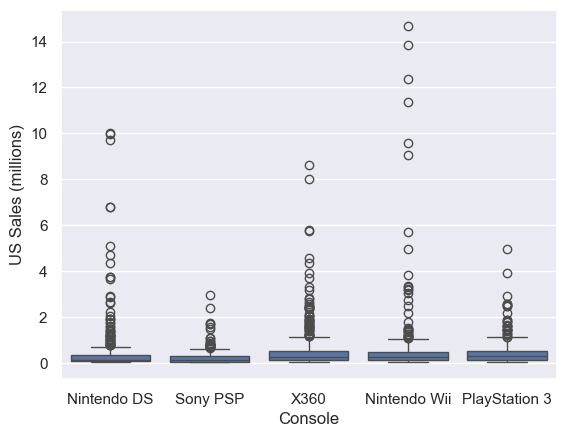

In [9]:
sns.boxplot(x="Console", y="US Sales (millions)", data=df)

In [10]:
consolesummary = df.groupby("Console")["US Sales (millions)"].describe()
consolesummary

,count,mean,std,min,25%,50%,75%,max
Console,,,,,,,,
Nintendo DS,418.0,0.447943,1.121021,0.01,0.06,0.12,0.3275,10.03
Nintendo Wii,296.0,0.691115,1.775619,0.01,0.10,0.26,0.4800,14.66
PlayStation 3,312.0,0.457564,0.588260,0.02,0.12,0.27,0.5225,4.95
Sony PSP,307.0,0.240326,0.339833,0.01,0.05,0.13,0.2800,2.97
X360,437.0,0.551190,0.927919,0.01,0.12,0.24,0.5200,8.61


The boxplot shows the distribution of U.S. sales (in millions) for each of the five consoles. Across all systems, most games sold fewer than 2 million copies, with a few blockbuster titles pushing sales well above 5 million. The Wii shows several games reaching very high sales, above 10 million units, while the other consoles have fewer extreme hits. The Sony PSP has noticeably lower sales overall, with most games selling under 1 million copies.

The numerical summary for US Sales (millions) reinforces this distribution. Out of 1,770 games, the average game sold about 0.48 million copies, while the median is much lower (0.19 million), indicating that the distribution is highly skewed to the right. The maximum observed sales value is 14.66 million, reflecting a top The results show that console type does matter. The Nintendo Wii and Xbox 360 stand out with more high-selling titles compared to the PSP, which consistently had lower sales per game. PlayStation 3 and Nintendo DS fall in between, with  distributions that include both low selling and a  high selling games.


To answer the question, the analysis shows that console type does influence sales outcomes, as the distribution of sales differs across platforms. The Nintendo Wii and Xbox 360 stand out with multiple popular games, some selling over 10 million copies, while the Sony PSP consistently had lower sales and very few high performing games. The Nintendo DS and PlayStation 3 fall in the middle, with a mix of average selling games and a few  successes. Numerical summaries confirm that although the average game sold fewer than half a million copies, certain consoles were more likely to host the more popular games. This indicates that platform popularity  played a role in shaping sales potential, showing that console type is an important factor in video game sales patterns.

## 5. Conclusion

In this project, we analyzed a video game dataset to explore the relationship between US Sales (millions) and Console type. The dataset included variables such as game title, console, and regional sales. Our research question focused on how sales vary across different gaming platforms. Using visualizations, such as our boxplot and the summary statistics , we were able to compare the distribution, median, mean, and quartiles of the US sales for each console. This analysis provided us insight into which consoles tend to generate higher sales, which can help video game companies make data based decisions about platform focus and marketing strategies. We were able to conclude that the type of console does influence US sales. 

One challege we faced in our data analysis was while trying to aggregate the sales data by console. We created a data frame that combines the data for each console to analyze. This was a problem because in combining the data by console, we lost a lot of detail in the variables of the data. There were no other missing data points or outliers that we could find. When describing our data frame, even the extreme values made sense to keep because they show cased the higher performing games which is benefitial information to anyone trying to devise a market strategy based on these games. Another limitation was the amount of variables, because there was not a variety of information to go off of. Other variables such as player engagement and game ratings may have helped us have more insight into the sales of these games. We did not face many other limitations in analyzing this data. 

Future work could help us expand this analysis by incorporating additional variables. We could look into game genre, release year, pricing per game, player engagement, or demographic information. Some research questions we could ask include: What is the relationship between game genre and US sales? Have US video game sales changed over time? Do certain games sell better in certain age groups? Analyzing these new variables could provide deeper insights into market strategy and profitability for certain video games.